In [1]:
# -*- coding: utf-8 -*- 
# Schrodinger generator   last updated by by kjsun 01/28/2026
import numpy as np
import torch
import sys
import time 
import matplotlib.pyplot as plt 
import copy
from argparse import ArgumentParser
import logging
from srcSG_utilities import device_info, check_device_and_seed, _to_tensor 

from srcSG_integrand import CustomDistribution
from srcSG_integrand import fun_ws as fun_integrand
from srcSG_plot import plot_ais,plot_training_data_2d,plot_SG,plot_SG2,plot_SG_full,plot_correlation_function_mixed_event_fast,plot_correlation_function_mixed_event_fast_in_chunks
from srcSG_AIS import SG_AIS_integrator,SG_AIS_sampler,SG_AIS_resampler,SG_AIS_inverse_mapping,SG_AIS_mapping
from srcSG_Flow import prepare_nf_training_data,create_flow_from_args,SG_sampler,train_flow,CombinedFlow,SG_Ana,update_flow_boundaries,eval_flow_in_chunks, SG_Ana_nucleus, SG_sampler_nucleus 
from srcSG_Flow import  SG_nucleus    
device = device_info()
seed = 12345
check_device_and_seed(device, seed)
torch.set_default_dtype(torch.float64)
dtype = torch.get_default_dtype()

In [2]:
Nd = 12
M=52
MA=18
MB=18
MC=M-MA-MB
Nit=251
param_ais_A,x_ais_resample_A,cluster_params_A,w_SG_A, x_SG_A,x_SG_R_A,trained_modelA,x_SG_resample_A=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MA,I_ais_only=0,seed=seed,Nit=Nit,device=device,dtype=dtype)

Running on device: cuda, dtype: torch.float64
01  I = 1.30392697e+02  +/- 2.87e+00   chi2/dof ~ 0.000
02  I = 1.29987553e+02  +/- 1.61e-01   chi2/dof ~ 0.010
03  I = 1.29810033e+02  +/- 6.72e-02   chi2/dof ~ 0.500
04  I = 1.29853718e+02  +/- 4.48e-02   chi2/dof ~ 0.566
05  I = 1.29859043e+02  +/- 3.56e-02   chi2/dof ~ 0.461
06  I = 1.29853940e+02  +/- 3.04e-02   chi2/dof ~ 0.396
07  I = 1.29843206e+02  +/- 2.70e-02   chi2/dof ~ 0.424
08  I = 1.29826586e+02  +/- 2.46e-02   chi2/dof ~ 0.644
09  I = 1.29820915e+02  +/- 2.27e-02   chi2/dof ~ 0.612
10  I = 1.29812724e+02  +/- 2.11e-02   chi2/dof ~ 0.651
11  I = 1.29745308e+02  +/- 2.94e-02   chi2/dof ~ 0.393
12  I = 1.29764279e+02  +/- 2.63e-02   chi2/dof ~ 0.734
13  I = 1.29750620e+02  +/- 2.40e-02   chi2/dof ~ 0.883
14  I = 1.29753297e+02  +/- 2.23e-02   chi2/dof ~ 0.769
15  I = 1.29748189e+02  +/- 2.09e-02   chi2/dof ~ 0.726
16  I = 1.29749070e+02  +/- 1.97e-02   chi2/dof ~ 0.647
17  I = 1.29752909e+02  +/- 1.86e-02   chi2/dof ~ 0.620
18

In [3]:
param_ais_A,x_ais_resample_A,cluster_params_A,w_SG_A, x_SG_A,x_SG_R_A,trained_modelA1,x_SG_resample_A=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MA,I_ais_only=0, seed=seed,Nit=Nit, trained_model=trained_modelA, device=device,dtype=dtype)

Running on device: cuda, dtype: torch.float64
01  I = 1.30392697e+02  +/- 2.87e+00   chi2/dof ~ 0.000
02  I = 1.29987553e+02  +/- 1.61e-01   chi2/dof ~ 0.010
03  I = 1.29810033e+02  +/- 6.72e-02   chi2/dof ~ 0.500
04  I = 1.29853718e+02  +/- 4.48e-02   chi2/dof ~ 0.566
05  I = 1.29859043e+02  +/- 3.56e-02   chi2/dof ~ 0.461
06  I = 1.29853940e+02  +/- 3.04e-02   chi2/dof ~ 0.396
07  I = 1.29843206e+02  +/- 2.70e-02   chi2/dof ~ 0.424
08  I = 1.29826586e+02  +/- 2.46e-02   chi2/dof ~ 0.644
09  I = 1.29820915e+02  +/- 2.27e-02   chi2/dof ~ 0.612
10  I = 1.29812724e+02  +/- 2.11e-02   chi2/dof ~ 0.651
11  I = 1.29745308e+02  +/- 2.94e-02   chi2/dof ~ 0.393
12  I = 1.29764279e+02  +/- 2.63e-02   chi2/dof ~ 0.734
13  I = 1.29750620e+02  +/- 2.40e-02   chi2/dof ~ 0.883
14  I = 1.29753297e+02  +/- 2.23e-02   chi2/dof ~ 0.769
15  I = 1.29748189e+02  +/- 2.09e-02   chi2/dof ~ 0.726
16  I = 1.29749070e+02  +/- 1.97e-02   chi2/dof ~ 0.647
17  I = 1.29752909e+02  +/- 1.86e-02   chi2/dof ~ 0.620
18

In [4]:
param_ais_B,x_ais_resample_B,cluster_params_B,w_SG_B, x_SG_B,x_SG_R_B,trained_modelB,x_SG_resample_B=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MB, I_ais_only=0, seed=seed,Nit=Nit,trained_model=trained_modelA,device=device,dtype=dtype)

Running on device: cuda, dtype: torch.float64
01  I = 1.30392697e+02  +/- 2.87e+00   chi2/dof ~ 0.000
02  I = 1.29987553e+02  +/- 1.61e-01   chi2/dof ~ 0.010
03  I = 1.29810033e+02  +/- 6.72e-02   chi2/dof ~ 0.500
04  I = 1.29853718e+02  +/- 4.48e-02   chi2/dof ~ 0.566
05  I = 1.29859043e+02  +/- 3.56e-02   chi2/dof ~ 0.461
06  I = 1.29853940e+02  +/- 3.04e-02   chi2/dof ~ 0.396
07  I = 1.29843206e+02  +/- 2.70e-02   chi2/dof ~ 0.424
08  I = 1.29826586e+02  +/- 2.46e-02   chi2/dof ~ 0.644
09  I = 1.29820915e+02  +/- 2.27e-02   chi2/dof ~ 0.612
10  I = 1.29812724e+02  +/- 2.11e-02   chi2/dof ~ 0.651
11  I = 1.29745308e+02  +/- 2.94e-02   chi2/dof ~ 0.393
12  I = 1.29764279e+02  +/- 2.63e-02   chi2/dof ~ 0.734
13  I = 1.29750620e+02  +/- 2.40e-02   chi2/dof ~ 0.883
14  I = 1.29753297e+02  +/- 2.23e-02   chi2/dof ~ 0.769
15  I = 1.29748189e+02  +/- 2.09e-02   chi2/dof ~ 0.726
16  I = 1.29749070e+02  +/- 1.97e-02   chi2/dof ~ 0.647
17  I = 1.29752909e+02  +/- 1.86e-02   chi2/dof ~ 0.620
18

Running on device: cuda, dtype: torch.float64
01  I = 1.30392697e+02  +/- 2.87e+00   chi2/dof ~ 0.000
02  I = 1.29987553e+02  +/- 1.61e-01   chi2/dof ~ 0.010
03  I = 1.29810033e+02  +/- 6.72e-02   chi2/dof ~ 0.500
04  I = 1.29853718e+02  +/- 4.48e-02   chi2/dof ~ 0.566
05  I = 1.29859043e+02  +/- 3.56e-02   chi2/dof ~ 0.461
06  I = 1.29853940e+02  +/- 3.04e-02   chi2/dof ~ 0.396
07  I = 1.29843206e+02  +/- 2.70e-02   chi2/dof ~ 0.424
08  I = 1.29826586e+02  +/- 2.46e-02   chi2/dof ~ 0.644
09  I = 1.29820915e+02  +/- 2.27e-02   chi2/dof ~ 0.612
10  I = 1.29812724e+02  +/- 2.11e-02   chi2/dof ~ 0.651
11  I = 1.29745308e+02  +/- 2.94e-02   chi2/dof ~ 0.393
12  I = 1.29764279e+02  +/- 2.63e-02   chi2/dof ~ 0.734
13  I = 1.29750620e+02  +/- 2.40e-02   chi2/dof ~ 0.883
14  I = 1.29753297e+02  +/- 2.23e-02   chi2/dof ~ 0.769
15  I = 1.29748189e+02  +/- 2.09e-02   chi2/dof ~ 0.726
16  I = 1.29749070e+02  +/- 1.97e-02   chi2/dof ~ 0.647
17  I = 1.29752909e+02  +/- 1.86e-02   chi2/dof ~ 0.620
18

UnboundLocalError: local variable 'z' referenced before assignment

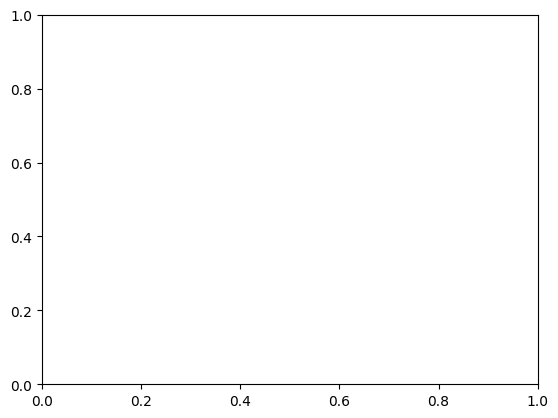

In [5]:
param_ais_C,x_ais_resample_C,cluster_params_C,w_SG_C, x_SG_C,x_SG_R_C,trained_modelC,x_SG_resample_C=SG_nucleus(fun_integrand,CustomDistribution,Nd=Nd, M=MC, I_ais_only=0,seed=seed,Nit=Nit,device=device,dtype=dtype)

In [ ]:
x_SG_resample_C.size()

In [ ]:
from srcSG_Flow import eval_flow_forward_in_chunks,eval_flow_in_chunks,eval_in_chunks, compute_ess
from srcSG_AIS import _safe_norm_weights,systematic_resample,residual_resample,metropolis_resample
x_SG_combine = torch.cat([x_SG_resample_A, x_SG_resample_B, x_SG_resample_C], dim=1)
a1 = _to_tensor(cluster_params_A['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params_A['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_resample_A - a1) / (b1 - a1)
f_vg_all_A,log_f_vg_all_A = eval_in_chunks(fun_integrand, s_vg, cluster_params_A, chunk_size=10000)

a1 = _to_tensor(cluster_params_B['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params_B['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_resample_B - a1) / (b1 - a1)
f_vg_all_B,log_f_vg_all_B = eval_in_chunks(fun_integrand, s_vg, cluster_params_B, chunk_size=10000)

a1 = _to_tensor(cluster_params_C['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params_C['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_resample_C - a1) / (b1 - a1)
f_vg_all_C,log_f_vg_all_C = eval_in_chunks(fun_integrand, s_vg, cluster_params_C, chunk_size=10000)

xmin=-11
xmax=11 
cluster_params = cluster_params_A.copy()  # your earlier param dictionary 
cluster_params['nd']=Nd*M
cluster_params['xmin'] = np.full(Nd*M, xmin)
cluster_params['xmax'] = np.full(Nd*M, xmax)


a1 = _to_tensor(cluster_params['xmin'], dtype=dtype, device=device)
b1 = _to_tensor(cluster_params['xmax'], dtype=dtype, device=device)
s_vg = (x_SG_combine - a1) / (b1 - a1)
f_vg_all,log_f_vg_all = eval_in_chunks(fun_integrand, s_vg, cluster_params, chunk_size=10000)
log_w_SG_combine = log_f_vg_all - log_f_vg_all_A-log_f_vg_all_B-log_f_vg_all_C

w_SG_combine = torch.exp(log_w_SG_combine+20)
w_SG_combine.mean()

In [ ]:
w_SG = w_SG_combine
s_SG = x_SG_combine
n_final = 100000
resample_method='systematic'
ESS = compute_ess(w_SG)
ESS_value = float(ESS.item())
n_prop = w_SG.shape[0]
ESS_frac = ESS_value / n_prop
    
print(f"ESS = {ESS_value:.1f} / {n_prop}  (ESS/N = {ESS_frac:.4f})")  
w_norm, total_w = _safe_norm_weights(w_SG)
ESS = 1.0 / torch.sum(w_norm ** 2)
ESS_value = float(ESS.item())
n_prop = s_SG.shape[0]
print('shape of w_FuHsi',w_SG.size()) 
if resample_method == 'systematic':
    idx = systematic_resample(w_norm, n_final, device=device)
elif resample_method == 'residual':
    idx = residual_resample(w_norm, n_final, device=device)
elif resample_method == 'metropolis':
    idx = metropolis_resample(
        w_norm, n_final,
        device=device,
         proposal_width=1000,
         thinning=100,
         warmup_steps=1000
    )
else:
    raise ValueError("resample_method must be 'systematic' or 'residual'")

x_SG_combine_resample = s_SG[idx]   # (n_final, Nd)

In [ ]:
#plt.figure(figsize=(10, 8))
#plt.plot(loss_hist)
#plt.title('Loss_{flow}')
#plt.show()

# if device.type=='cpu':   
print(x_ais_resample_A.size())
print(x_SG_combine_resample.size())
#plot_SG2(x0,x_ais,x0_resample,x_ais_resample,x_SG_combine_resample)

if M<10:
    Na = 1000
    Nb = 100000
else:
    Na = 10000
    Nb = 1000000
#plot_correlation_function_mixed_event_fast_in_chunks(x_train,Na,Nb,device=device)
#plot_correlation_function_mixed_event_fast_in_chunks(x_train_B,Na,Nb,device=device)
#plot_correlation_function_mixed_event_fast_in_chunks(x_train_C,Na,Nb,device=device)

#plot_correlation_function_mixed_event_fast_in_chunks(x_test,Na,Nb,device=device) 
#plot_correlation_function_mixed_event_fast_in_chunks(x_test_B,Na,Nb,device=device)
#plot_training_data_2d(x_train_C.to('cpu'), dim1=0, dim2=1, bins=100, scatter=True, hist2d=True) 
#bin_nf,C_dr_nf=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_nf,Na,Nb,device=device)\\

#bin_nf,C_dr_nf=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_R_C,Na,Nb,device=device)

bin_SG_ini,C_dr_SG_ini=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_resample_C,Na,Nb,device=device)
#bin_SG_ini,C_dr_SG_ini=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_R_B,Na,Nb,device=device)
bin_SG,C_dr_SG=plot_correlation_function_mixed_event_fast_in_chunks(x_SG_combine_resample,Na,Nb,device=device)
bin_AIS_Resample,C_dr_AIS_Resample=plot_correlation_function_mixed_event_fast_in_chunks(x_ais_resample_A,Na,Nb,device=device)

plt.figure()

#plt.plot(bin_nf.cpu(), C_dr_nf.cpu(),'-k.') 
plt.plot(bin_AIS_Resample.cpu(), C_dr_AIS_Resample.cpu(),'-b.') 
plt.plot(bin_SG_ini.cpu(), C_dr_SG_ini.cpu(),'-c.') 
plt.plot(bin_SG.cpu(), C_dr_SG.cpu(),'-r.') 
plt.axhline(1.0, color='c', linestyle='--')
plt.xlim(0, 4)
plt.ylim(0, 1.6)
plt.show()


print("Dimension = ",Nd*M)
#print("Monte Carlo 积分近似结果:", I_ini,err_ini, I_ais, err_ais,  I_SG, err_SG)
#print("SG-Uniform: Loss = ",  Loss_KL_ini)
#print("SG-vg: Loss = ",  Loss_KL_ais)
#print("SG-NF: Loss = ",  Loss_KL_sg)

In [ ]:
def jastrow_factor(rij, a, b, c, d, e, f):
    """
    X: (B, N, 3)
    Computes Jastrow without forming full (B,N,N) tensor
    """
     
    term = 1 + a * torch.exp(-b * rij**2) * (
        c + d*rij**2 + e*rij**3 + f*rij**4) 

 
    return  term

r = torch.linspace(0,4,21)
g = jastrow_factor(r, -1,1.2627,0.9916,2.1032,-6.1297,2.9348)


plt.figure()
#plt.plot(bin_AIS_Resample.cpu(), C_dr_AIS_Resample.cpu(),'-b.') 
plt.plot(bin_SG.cpu(), C_dr_SG.cpu(),'-r.') 

plt.plot(bin_SG_ini.cpu(), C_dr_SG_ini.cpu(),'-c.') 
plt.plot(r.cpu(), g.cpu(),'--k') 
#plt.axhline(1.0, color='r', linestyle='--')
plt.xlim(0, 4)
plt.ylim(0, 1.6)
plt.show() 
data = np.column_stack((bin_SG.cpu().numpy(), C_dr_SG.cpu().numpy()))
np.savetxt("results/SG_nuclei_src_" +str(Nd*M) + "d.txt", data)

In [ ]:
C_dr_SG

In [ ]:
import torch
import gc

def sizeof_tensor(t):
    return t.numel() * t.element_size()

def scan_obj(name, obj, results):
    
    if torch.is_tensor(obj) and obj.is_cuda:
        results.append((name, sizeof_tensor(obj), tuple(obj.shape), obj.dtype))
        
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            scan_obj(f"{name}[{i}]", v, results)
            
    elif isinstance(obj, dict):
        for k, v in obj.items():
            scan_obj(f"{name}[{k}]", v, results)
            
    elif hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            scan_obj(f"{name}.{k}", v, results)


def gpu_memory_report(topn=10):
    
    results = []
    
    for name, obj in globals().items():
        try:
            scan_obj(name, obj, results)
        except:
            pass

    results.sort(key=lambda x: x[1], reverse=True)

    print(f"\nTop {topn} GPU tensors:\n")
    print(f"{'Name':35} {'Memory(MB)':>12} {'Shape':>20} {'Type'}")
    print("-"*80)

    for name, size, shape, dtype in results[:topn]:
        print(f"{name:35} {size/1024**2:12.2f} {str(shape):>20} {dtype}")

    print("\nGPU Summary")
    print("-"*40)
    print("Allocated:", torch.cuda.memory_allocated()/1024**3, "GB")
    print("Reserved :", torch.cuda.memory_reserved()/1024**3, "GB")

In [ ]:
gpu_memory_report(10)

In [ ]:
#del x_SG_combine,s_SG,s_vg,x_SG_combine_resample,x_SG_resample_A,x_SG_resample_B
#del s_vg
#del x_SG_resample_A,x_SG_A,x_SG_B
#del  x_SG_A, x_SG_B, x_SG_combine,s_vg, x_SG_resample_A,x_SG_resample_B
#del x_SG_, x_ais_B_,   w_SG_,   J_ais, idx, status
gc.collect()
torch.cuda.empty_cache()